# MNIST digit classification with an MLP

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/gabrielca5/InsperAI26.1/blob/main/handout/docs/aula-06/mnist-mlp-handout.ipynb)

**InsperAI Trainees · Lesson 6 (Training in Practice) + Project 1**

This notebook is **complete**: run it top to bottom and read along. It takes a
few minutes on a CPU. You will see the whole pipeline the project asks for:

1. load the digits and look at them;
2. prepare them for training (scale, split, batch);
3. build an MLP and check it before training;
4. train it, watching the training and validation curves;
5. evaluate it and see where it fails;
6. create a Kaggle submission file.

It runs in two places without changes: on **Kaggle** (it reads the competition
files) and on **Colab** (it downloads MNIST with `torchvision`).

In [1]:
import os
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from sklearn.model_selection import train_test_split
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

torch.manual_seed(42)   # same initial weights and batch order every run
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("running on:", device)

running on: cpu


## The knobs

These are the **hyperparameters**: choices you make before training. Everything
in the project is about choosing them well. Change one at a time and rerun.

In [2]:
BATCH_SIZE = 64        # images per weight update
LEARNING_RATE = 0.001  # step size (0.001 is the usual start for Adam)
EPOCHS = 10            # full passes over the training images
HIDDEN = 512           # neurons in each hidden layer

## 1. Load the data

On Kaggle, the competition gives two CSV files: `train.csv` (images **with**
labels) and `test.csv` (images **without** labels, the ones you predict and
submit). Each row is one image: 784 columns `pixel0` to `pixel783`, values from
0 (black) to 255 (white).

Outside Kaggle, the cell falls back to the original MNIST from `torchvision`,
so the rest of the notebook works the same.

In [3]:
KAGGLE_DIR = "../input/digit-recognizer/"

if os.path.exists(KAGGLE_DIR):
    train_df = pd.read_csv(KAGGLE_DIR + "train.csv")
    test_df = pd.read_csv(KAGGLE_DIR + "test.csv")
    images = train_df.drop(columns="label").to_numpy().reshape(-1, 28, 28)
    labels = train_df["label"].to_numpy()
    test_images = test_df.to_numpy().reshape(-1, 28, 28)
    print("source: Kaggle competition files")
else:
    from torchvision import datasets
    train_set = datasets.MNIST(".", train=True, download=True)
    test_set = datasets.MNIST(".", train=False, download=True)
    images, labels = train_set.data.numpy(), train_set.targets.numpy()
    test_images = test_set.data.numpy()
    print("source: torchvision MNIST")

print("labeled images:", images.shape, "| test images:", test_images.shape)
print("pixel range:", images.min(), "to", images.max())

source: torchvision MNIST
labeled images: (60000, 28, 28) | test images: (10000, 28, 28)
pixel range: 0 to 255


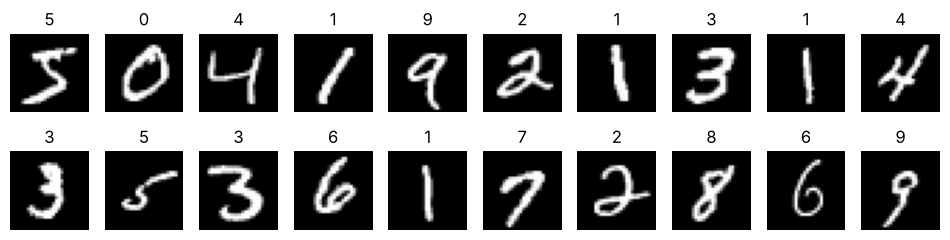

images per digit: [5923 6742 5958 6131 5842 5421 5918 6265 5851 5949]


In [4]:
fig, axes = plt.subplots(2, 10, figsize=(12, 2.8))
for ax, img, label in zip(axes.flat, images, labels):
    ax.imshow(img, cmap="gray")
    ax.set_title(label)
    ax.axis("off")
plt.show()

print("images per digit:", np.bincount(labels))

The classes are roughly balanced, so accuracy is a fair metric here.

### What the network actually sees

To the network, an image is just a grid of numbers. Here is one digit with each
pixel's value, already divided by 255:

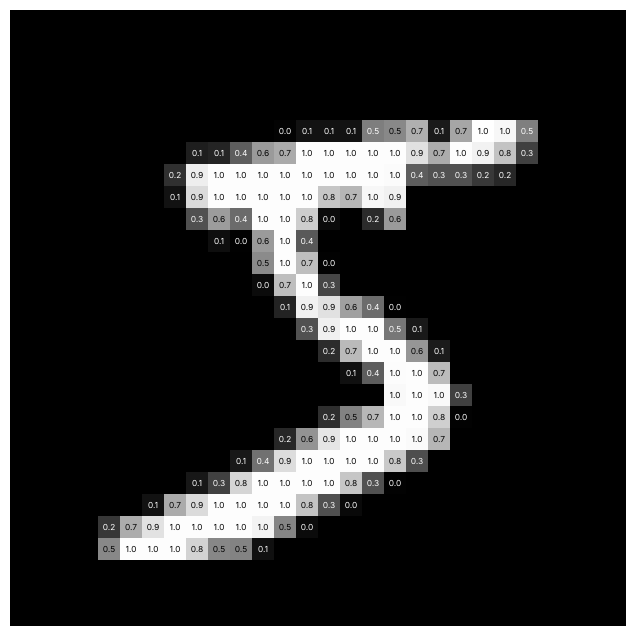

In [5]:
img = images[0] / 255
fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(img, cmap="gray")
for row in range(28):
    for col in range(28):
        if img[row, col] > 0:
            ax.text(col, row, f"{img[row, col]:.1f}", ha="center", va="center", fontsize=6,
                    color="black" if img[row, col] > 0.5 else "white")
ax.axis("off")
plt.show()

## 2. Prepare the data

Three steps:

- **Scale** pixels from 0–255 to 0–1. Networks train badly with large inputs.
- **Split** 20% of the labeled images into a **validation** set. The model never
  trains on them, so they tell us how it does on images it has not seen.
  `stratify` keeps the same proportion of each digit in both parts.
- **Batch** with a `DataLoader`. Each batch produces one weight update
  (one **iteration**); one pass over all training images is one **epoch**.

In [6]:
train_x, valid_x, train_y, valid_y = train_test_split(
    images, labels, test_size=0.2, stratify=labels, random_state=42)


def to_tensor(x):
    return torch.tensor(x, dtype=torch.float32) / 255   # scale to 0-1


train_ds = TensorDataset(to_tensor(train_x), torch.tensor(train_y))
valid_ds = TensorDataset(to_tensor(valid_x), torch.tensor(valid_y))

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)   # new order every epoch
valid_loader = DataLoader(valid_ds, batch_size=1000)

print(f"train: {len(train_ds)} images -> {len(train_loader)} batches of {BATCH_SIZE} per epoch")
print(f"valid: {len(valid_ds)} images")
print(f"{EPOCHS} epochs = {EPOCHS * len(train_loader)} weight updates")

train: 48000 images -> 750 batches of 64 per epoch
valid: 12000 images
10 epochs = 7500 weight updates


## 3. Build the network

An MLP (multi-layer perceptron): the 28×28 image is flattened into 784 numbers,
goes through two hidden layers with ReLU, and comes out as **10 scores**, one per
digit.

Two details:

- There is **no softmax** at the end, because `CrossEntropyLoss` applies it
  internally. Adding one here is a classic bug.
- `Dropout` randomly turns off 20% of the neurons during training, which helps
  against overfitting. It is a Lesson 7 topic; set it to 0 to see the difference.

In [7]:
model = nn.Sequential(
    nn.Flatten(),                     # 28x28 -> 784
    nn.Linear(784, HIDDEN), nn.ReLU(), nn.Dropout(0.2),
    nn.Linear(HIDDEN, HIDDEN), nn.ReLU(), nn.Dropout(0.2),
    nn.Linear(HIDDEN, 10),            # 10 scores, one per digit
).to(device)

print(model)
print(f"\nparameters: {sum(p.numel() for p in model.parameters()):,}")

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=512, bias=True)
  (2): ReLU()
  (3): Dropout(p=0.2, inplace=False)
  (4): Linear(in_features=512, out_features=512, bias=True)
  (5): ReLU()
  (6): Dropout(p=0.2, inplace=False)
  (7): Linear(in_features=512, out_features=10, bias=True)
)

parameters: 669,706


### Sanity check: the first loss should be about 2.30

An untrained network guesses about 10% for each digit. The cross-entropy of that
guess is $-\ln(0.1) = 2.30$. If the first loss is far from this, something is
wrong with the data or the model **before** training even starts.

In [8]:
loss_fn = nn.CrossEntropyLoss()

x, y = next(iter(train_loader))
with torch.no_grad():
    first_loss = loss_fn(model(x.to(device)), y.to(device)).item()
print(f"expected: {-np.log(0.1):.2f}   untrained model: {first_loss:.2f}")

expected: 2.30   untrained model: 2.31


## 4. Train

Each iteration repeats the same four steps:

1. **forward**: the batch goes through the network;
2. **loss**: measure how wrong the predictions are;
3. **backward**: `loss.backward()` computes the gradient of every weight;
4. **step**: the optimizer (Adam) updates the weights.

After each epoch we measure the loss and accuracy on the validation set, and we
**save the model whenever the validation loss improves**. That way we keep the
best version, not just the last one.

In [9]:
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)


def evaluate(model, loader):
    model.eval()                        # turns dropout off
    total_loss, correct = 0.0, 0
    with torch.no_grad():               # no gradients needed to evaluate
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            scores = model(x)
            total_loss += loss_fn(scores, y).item() * len(y)
            correct += (scores.argmax(dim=1) == y).sum().item()
    return total_loss / len(loader.dataset), correct / len(loader.dataset)


history = {"train_loss": [], "valid_loss": [], "valid_acc": []}
best_valid_loss = np.inf
start = time.time()

for epoch in range(EPOCHS):
    model.train()                       # turns dropout on
    running_loss = 0.0
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        loss = loss_fn(model(x), y)     # forward + loss
        optimizer.zero_grad()           # clear the previous batch's gradients
        loss.backward()                 # backward
        optimizer.step()                # step
        running_loss += loss.item() * len(y)

    train_loss = running_loss / len(train_ds)
    valid_loss, valid_acc = evaluate(model, valid_loader)
    history["train_loss"].append(train_loss)
    history["valid_loss"].append(valid_loss)
    history["valid_acc"].append(valid_acc)

    saved = ""
    if valid_loss < best_valid_loss:
        best_valid_loss = valid_loss
        torch.save(model.state_dict(), "best_model.pt")
        saved = "  <- best so far, saved"
    print(f"epoch {epoch + 1:2d} | train loss {train_loss:.4f} | valid loss {valid_loss:.4f} "
          f"| valid acc {valid_acc:.2%}{saved}")

print(f"\ntraining took {time.time() - start:.0f} s")

epoch  1 | train loss 0.2716 | valid loss 0.1354 | valid acc 95.83%  <- best so far, saved


epoch  2 | train loss 0.1148 | valid loss 0.0992 | valid acc 96.96%  <- best so far, saved


epoch  3 | train loss 0.0825 | valid loss 0.0918 | valid acc 97.19%  <- best so far, saved


epoch  4 | train loss 0.0627 | valid loss 0.0893 | valid acc 97.36%  <- best so far, saved


epoch  5 | train loss 0.0534 | valid loss 0.0818 | valid acc 97.71%  <- best so far, saved


epoch  6 | train loss 0.0476 | valid loss 0.0792 | valid acc 98.00%  <- best so far, saved


epoch  7 | train loss 0.0397 | valid loss 0.0831 | valid acc 97.88%


epoch  8 | train loss 0.0346 | valid loss 0.0832 | valid acc 98.02%


epoch  9 | train loss 0.0353 | valid loss 0.0905 | valid acc 97.87%


epoch 10 | train loss 0.0304 | valid loss 0.0891 | valid acc 97.97%

training took 89 s


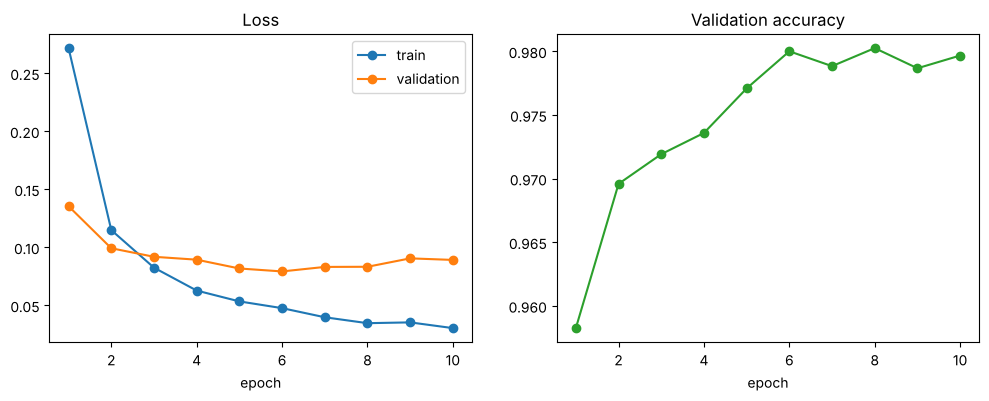

In [10]:
epochs = range(1, EPOCHS + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(epochs, history["train_loss"], "o-", label="train")
ax1.plot(epochs, history["valid_loss"], "o-", label="validation")
ax1.set(title="Loss", xlabel="epoch")
ax1.legend()
ax2.plot(epochs, history["valid_acc"], "o-", color="tab:green")
ax2.set(title="Validation accuracy", xlabel="epoch")
plt.show()

**How to read these curves.** The training loss keeps going down: the network
keeps getting better at the images it trains on. The validation loss drops fast
and then **stops improving or goes up**, while the accuracy flattens out. From
that point on, extra epochs fit the training images, not new ones. This is
called **overfitting**, and it is the subject of Lesson 7. It is also why we
saved the best model instead of the last one.

## 5. Evaluate the best model

In [11]:
model.load_state_dict(torch.load("best_model.pt"))
model.eval()

with torch.no_grad():
    valid_pred = model(valid_ds.tensors[0].to(device)).argmax(dim=1).cpu().numpy()

print(f"overall validation accuracy: {(valid_pred == valid_y).mean():.2%}\n")
for digit in range(10):
    mask = valid_y == digit
    print(f"digit {digit}: {(valid_pred[mask] == digit).mean():.1%}  ({mask.sum()} images)")

overall validation accuracy: 98.00%

digit 0: 99.2%  (1185 images)
digit 1: 99.0%  (1348 images)
digit 2: 97.2%  (1192 images)
digit 3: 98.1%  (1226 images)
digit 4: 98.0%  (1168 images)
digit 5: 98.2%  (1084 images)
digit 6: 97.7%  (1184 images)
digit 7: 98.6%  (1253 images)
digit 8: 97.1%  (1170 images)
digit 9: 96.6%  (1190 images)


Accuracy alone hides **which** digits get confused. Looking at the mistakes is
the fastest way to understand a model:

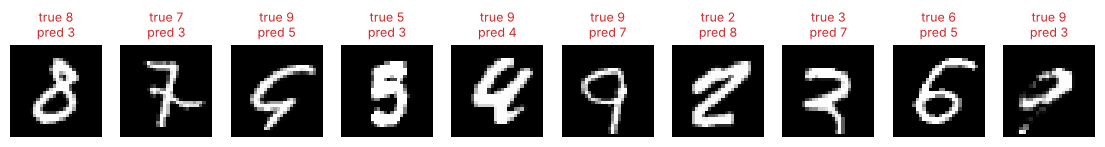

In [12]:
wrong = np.flatnonzero(valid_pred != valid_y)[:10]
fig, axes = plt.subplots(1, 10, figsize=(14, 2.2))
for ax, i in zip(axes, wrong):
    ax.imshow(valid_x[i], cmap="gray")
    ax.set_title(f"true {valid_y[i]}\npred {valid_pred[i]}", color="tab:red", fontsize=9)
    ax.axis("off")
plt.show()

Many of these would make a person hesitate too. That is why nobody reaches 100%
on MNIST, and why chasing the last tenths of a percent is hard.

## 6. Kaggle: how the competition works

[Kaggle](https://www.kaggle.com) hosts machine learning competitions. The
project uses the **[Digit Recognizer](https://www.kaggle.com/competitions/digit-recognizer)**
format. What you need to know:

- **Data tab.** `train.csv` has the labels; `test.csv` does not. You never see
  the test labels: Kaggle keeps them to grade you.
- **Notebooks.** You can code directly on Kaggle (*Code → New Notebook*). The
  competition files appear in `../input/digit-recognizer/`, which is the path the
  first cell of this notebook looks for. You can also upload this `.ipynb` there
  (*File → Import Notebook*).
- **Submission.** You submit a CSV with one prediction per test image, in the
  exact format of `sample_submission.csv`: columns `ImageId` (starting at 1)
  and `Label`.
- **Leaderboard.** Your score (accuracy here) is computed on part of the test
  set and shown on the **public** leaderboard. When a competition ends, the
  final ranking uses the **private** part, which nobody saw. Tuning your model to
  climb the public leaderboard tends to backfire there: decide using **your
  validation set**.
- **Limits.** There is a maximum number of submissions per day, so test your ideas
  on validation first and submit only what is worth it.

Creating the submission file:

In [13]:
test_tensor = to_tensor(test_images).to(device)
with torch.no_grad():
    test_pred = model(test_tensor).argmax(dim=1).cpu().numpy()

submission = pd.DataFrame({"ImageId": np.arange(1, len(test_pred) + 1), "Label": test_pred})
submission.to_csv("submission.csv", index=False)
submission.head()

,ImageId,Label
0,1,7
1,2,2
2,3,1
3,4,0
4,5,4


**To submit:** on Kaggle, save the notebook with *Save Version → Save & Run All*,
open the version, go to the *Output* tab and click *Submit*. Or download
`submission.csv` and upload it on the competition page (*Submit Prediction*).

> Running this notebook outside Kaggle, `test_images` are the 10,000 MNIST test
> images, so the file has the right **format** but is not the competition's
> test set. Use the Kaggle files when you submit for real.

## Try it yourself

Change **one** knob at a time, rerun, and write down the best validation accuracy:

- `LEARNING_RATE` = 0.01 or 0.0001. What happens to the curves?
- `BATCH_SIZE` = 16 or 256. How do time per epoch and accuracy change?
- `HIDDEN` = 128 or 1024. Is a bigger network always better?
- Remove both `Dropout` layers. Does overfitting start earlier?